# 04 - Modelado Multivariado: Regresión Logística y Eliminación Hacia Atrás

Se ajusta un modelo de regresión logística multivariada para `alteracion_osea` usando codificación explícita de categorías de referencia y eliminación hacia atrás basada en el valor p de Wald.

In [1]:
import os
from html import escape
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import HTML, display
from sklearn.metrics import auc, roc_curve

pd.set_option("display.max_columns", None)

APA_TABLE_CSS = """
<style>
.apa-table-wrap{max-width:1040px;overflow-x:auto;background:#fff!important;color:#111!important;color-scheme:light;padding:20px 22px;border:1px solid #d7d2c3;box-shadow:0 2px 8px rgba(0,0,0,.16);font-family:'Times New Roman',Times,serif;}
.apa-table-wrap *{box-sizing:border-box;color:#111!important;opacity:1!important;}
.apa-table-number{background:#fff!important;font-size:15px;font-weight:700;line-height:1.35;margin:0 0 2px 0;}
.apa-table-title{background:#fff!important;font-size:15px;font-style:italic;line-height:1.35;margin:0 0 12px 0;}
.apa-table{border-collapse:collapse;min-width:760px;width:100%;background:#fff!important;font-size:13.5px;line-height:1.3;}
.apa-table th{background:#fff!important;border-top:2px solid #111;border-bottom:1.5px solid #111;padding:7px 9px;text-align:center;font-weight:700;vertical-align:bottom;}
.apa-table td{background:#fff!important;border-bottom:none;padding:6px 9px;vertical-align:middle;}
.apa-table tbody tr:last-child td{border-bottom:2px solid #111;}
.apa-table .text{text-align:left;}
.apa-table .num{text-align:right;white-space:nowrap;}
.apa-note{background:#fff!important;font-size:12.5px;line-height:1.35;margin:10px 0 0 0;}
.apa-note .label{font-style:italic;}
</style>
"""

def render_apa_table(table, number, title, note=None):
    html = [APA_TABLE_CSS, "<div class='apa-table-wrap'>"]
    html.append(f"<p class='apa-table-number'>Tabla {escape(str(number))}</p>")
    html.append(f"<p class='apa-table-title'>{escape(title)}</p>")
    html.append("<table class='apa-table'><thead><tr>")

    for column in table.columns:
        html.append(f"<th>{escape(str(column))}</th>")
    html.append("</tr></thead><tbody>")

    for _, row in table.iterrows():
        html.append("<tr>")
        for column, value in row.items():
            is_number = isinstance(value, (int, float, np.integer, np.floating))
            css_class = "num" if is_number and column != "Variable" else "text"
            html.append(f"<td class='{css_class}'>{escape(str(value))}</td>")
        html.append("</tr>")

    html.append("</tbody></table>")
    if note:
        html.append(f"<p class='apa-note'><span class='label'>Nota.</span> {escape(note)}</p>")
    html.append("</div>")
    return HTML("".join(html))



In [2]:
if "df_clean" not in globals():
    processed_dir = Path("/home/marcos-maravilla/análisis_estadístico_osteoporosis/data/processed")
    parquet_path = processed_dir / "BD_Clean_Osteoporosis.parquet"
    pickle_path = processed_dir / "BD_Clean_Osteoporosis.pkl"
    try:
        df_clean = pd.read_parquet(parquet_path)
    except Exception:
        df_clean = pd.read_pickle(pickle_path)

y = df_clean["alteracion_osea"].copy()
predictoras_iniciales = ["edad", "imc", "sexo", "trabaja", "enfermedad_cat", "realiza_af"]
model_data = df_clean[["alteracion_osea", *predictoras_iniciales]].copy()

def codificar_binaria(serie, mapa, nombre_variable):
    valores = serie.astype("string").str.strip().str.lower()
    codificada = valores.map(mapa)
    if codificada.isna().any():
        valores_no_mapeados = sorted(valores.loc[codificada.isna()].dropna().unique())
        raise ValueError(f"Valores no mapeados en {nombre_variable}: {valores_no_mapeados}")
    return codificada.astype(int)

mapas_binarios = {
    "sexo": {"0": 0, "0.0": 0, "hombre": 0, "1": 1, "1.0": 1, "mujer": 1},
    "trabaja": {"0": 0, "0.0": 0, "no": 0, "1": 1, "1.0": 1, "sí": 1, "si": 1},
    "realiza_af": {"0": 0, "0.0": 0, "no": 0, "1": 1, "1.0": 1, "sí": 1, "si": 1},
}

model_data["alteracion_osea"] = pd.to_numeric(model_data["alteracion_osea"], errors="coerce")
model_data["edad"] = pd.to_numeric(model_data["edad"], errors="coerce")
model_data["imc"] = pd.to_numeric(model_data["imc"], errors="coerce")
model_data["enfermedad_cat"] = pd.to_numeric(model_data["enfermedad_cat"], errors="coerce")
model_data["sexo"] = codificar_binaria(model_data["sexo"], mapas_binarios["sexo"], "sexo")
model_data["trabaja"] = codificar_binaria(model_data["trabaja"], mapas_binarios["trabaja"], "trabaja")
model_data["realiza_af"] = codificar_binaria(model_data["realiza_af"], mapas_binarios["realiza_af"], "realiza_af")
model_data = model_data.dropna().copy()

y = model_data["alteracion_osea"].astype(int)
X_base = model_data[["edad", "imc", "sexo", "trabaja", "realiza_af"]].astype(float)

if model_data["enfermedad_cat"].nunique() > 2:
    enfermedad_dummies = pd.get_dummies(
        model_data["enfermedad_cat"].astype(int).astype("category"),
        prefix="enfermedad_cat",
        drop_first=True,
        dtype=float,
    )
    X_encoded = pd.concat([X_base, enfermedad_dummies], axis=1)
else:
    X_encoded = X_base.assign(enfermedad_cat=model_data["enfermedad_cat"].astype(float))

X_inicial = sm.add_constant(X_encoded.astype(float), has_constant="add")

print(f"Observaciones incluidas: {len(model_data):,}")
print("Codificación de referencia: sexo Hombre=0/Mujer=1; trabaja No=0/Sí=1; realiza_af No=0/Sí=1.")
print(f"Variables iniciales del modelo: {list(X_inicial.columns)}")

Observaciones incluidas: 405
Codificación de referencia: sexo Hombre=0/Mujer=1; trabaja No=0/Sí=1; realiza_af No=0/Sí=1.
Variables iniciales del modelo: ['const', 'edad', 'imc', 'sexo', 'trabaja', 'realiza_af', 'enfermedad_cat_1', 'enfermedad_cat_2']


In [3]:
def ajustar_logit(y, X):
    return sm.Logit(y, X).fit(method="bfgs", disp=False, maxiter=200)

X_current = X_inicial.copy()
historial_backward = []

while True:
    modelo_actual = ajustar_logit(y, X_current)
    valores_p = modelo_actual.pvalues.drop("const")
    variable_peor_p = valores_p.idxmax()
    p_max = float(valores_p.max())
    accion = "Eliminar" if p_max > 0.10 else "Detener"

    historial_backward.append(
        {
            "Iteración": len(historial_backward) + 1,
            "Variables": ", ".join(X_current.columns.drop("const")),
            "Variable con mayor p": variable_peor_p,
            "p máximo": p_max,
            "Acción": accion,
        }
    )

    if p_max <= 0.10:
        modelo_final = modelo_actual
        X_final = X_current.copy()
        break

    X_current = X_current.drop(columns=variable_peor_p)

historial_backward = pd.DataFrame(historial_backward)
display(render_apa_table(
    historial_backward,
    "S1",
    "Proceso de eliminación hacia atrás del modelo logístico",
    "El criterio de permanencia fue p <= 0.10; la variable con mayor valor p se eliminó en cada iteración.",
))
variables_retenidas = list(X_final.columns.drop("const"))
print(f"Variables retenidas en el modelo final: {variables_retenidas}")

Iteración,Variables,Variable con mayor p,p máximo,Acción
1,"edad, imc, sexo, trabaja, realiza_af, enfermedad_cat_1, enfermedad_cat_2",enfermedad_cat_2,0.9864233209794236,Eliminar
2,"edad, imc, sexo, trabaja, realiza_af, enfermedad_cat_1",realiza_af,0.7884603903203922,Eliminar
3,"edad, imc, sexo, trabaja, enfermedad_cat_1",trabaja,0.6167518445028027,Eliminar
4,"edad, imc, sexo, enfermedad_cat_1",enfermedad_cat_1,0.4797200506945217,Eliminar
5,"edad, imc, sexo",sexo,0.0024168306005080513,Detener


Variables retenidas en el modelo final: ['edad', 'imc', 'sexo']


In [4]:
def formatear_p(valor):
    return "< 0.001" if valor < 0.001 else f"{valor:.3f}"

etiquetas_variables = {
    "const": "Intercepto",
    "edad": "Edad",
    "imc": "IMC",
    "sexo": "Sexo: mujer vs hombre",
    "trabaja": "Trabaja: sí vs no",
    "realiza_af": "Actividad física: sí vs no",
    "enfermedad_cat": "Enfermedad",
    "enfermedad_cat_1": "Enfermedad: síndrome metabólico vs sano",
    "enfermedad_cat_2": "Enfermedad: otras enfermedades vs sano",
}

parametros = modelo_final.params
intervalos = modelo_final.conf_int()

tabla_regresion = pd.DataFrame(
    {
        "Variable": [etiquetas_variables.get(variable, variable) for variable in parametros.index],
        "Coeficiente (B)": parametros.round(3).values,
        "Error Estándar": modelo_final.bse.round(3).values,
        "Valor p": [formatear_p(valor) for valor in modelo_final.pvalues.values],
        "OR": np.exp(parametros).round(2).values,
        "IC 95% Inferior": np.exp(intervalos[0]).round(2).values,
        "IC 95% Superior": np.exp(intervalos[1]).round(2).values,
    }
)

nota_tabla = (
    "B = coeficiente logit; OR = odds ratio; IC = intervalo de confianza. "
    "La categoría de referencia para sexo es Hombre (0); para trabaja y actividad física es No (0). "
    "El modelo final proviene de eliminación hacia atrás con criterio p <= 0.10."
)

display(render_apa_table(tabla_regresion, 3, "Modelo de regresión logística multivariada para alteración ósea", nota_tabla))

Variable,Coeficiente (B),Error Estándar,Valor p,OR,IC 95% Inferior,IC 95% Superior
Intercepto,1.073,1.84,0.560,2.92,0.08,107.8
Edad,0.147,0.026,< 0.001,1.16,1.1,1.22
IMC,-0.313,0.045,< 0.001,0.73,0.67,0.8
Sexo: mujer vs hombre,1.334,0.44,0.002,3.8,1.6,8.99


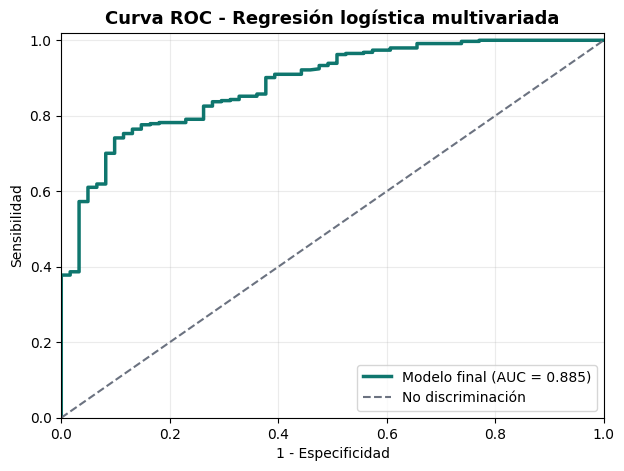

AUC: 0.8846


In [5]:
y_pred_prob = modelo_final.predict(X_final)
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
auc_modelo = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="#0f766e", linewidth=2.5, label=f"Modelo final (AUC = {auc_modelo:.3f})")
ax.plot([0, 1], [0, 1], color="#6b7280", linestyle="--", linewidth=1.5, label="No discriminación")
ax.set_title("Curva ROC - Regresión logística multivariada", fontsize=13, weight="bold")
ax.set_xlabel("1 - Especificidad")
ax.set_ylabel("Sensibilidad")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right", frameon=True)
ax.grid(alpha=0.25)
plt.show()

print(f"AUC: {auc_modelo:.4f}")

In [6]:
RESULTS_DIR = Path("/home/marcos-maravilla/análisis_estadístico_osteoporosis/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ROC_PATH = RESULTS_DIR / "curva_roc.pdf"
EXCEL_PATH = RESULTS_DIR / "tabla_3_multivariado.xlsx"
HTML_PATH = RESULTS_DIR / "tabla_3_estilo_apa.html"

fig_export, ax_export = plt.subplots(figsize=(7, 5))
ax_export.plot(
    fpr,
    tpr,
    color="#0f766e",
    linewidth=2.5,
    label=f"Modelo final (AUC = {auc_modelo:.3f})",
)
ax_export.plot(
    [0, 1],
    [0, 1],
    color="#6b7280",
    linestyle="--",
    linewidth=1.5,
    label="No discriminación",
)
ax_export.set_title("Curva ROC - Regresión logística multivariada", fontsize=13, weight="bold")
ax_export.set_xlabel("1 - Especificidad")
ax_export.set_ylabel("Sensibilidad")
ax_export.set_xlim(0, 1)
ax_export.set_ylim(0, 1.02)
ax_export.legend(loc="lower right", frameon=True)
ax_export.grid(alpha=0.25)
plt.savefig(ROC_PATH, dpi=300, bbox_inches="tight")
plt.close(fig_export)

tabla_regresion.to_excel(EXCEL_PATH, index=False)

tabla_3_html = render_apa_table(
    tabla_regresion,
    3,
    "Modelo de regresión logística multivariada para alteración ósea",
    nota_tabla,
).data
HTML_PATH.write_text(tabla_3_html, encoding="utf-8")

print("Elementos exportados correctamente:")
print(f"- Curva ROC: {ROC_PATH}")
print(f"- Tabla multivariada Excel: {EXCEL_PATH}")
print(f"- Tabla APA HTML: {HTML_PATH}")

Elementos exportados correctamente:
- Curva ROC: /home/marcos-maravilla/análisis_estadístico_osteoporosis/results/curva_roc.pdf
- Tabla multivariada Excel: /home/marcos-maravilla/análisis_estadístico_osteoporosis/results/tabla_3_multivariado.xlsx
- Tabla APA HTML: /home/marcos-maravilla/análisis_estadístico_osteoporosis/results/tabla_3_estilo_apa.html


In [7]:
MARKDOWN_PATH = RESULTS_DIR / "informe_resultados.md"


def obtener_fila_resultado(variable):
    return tabla_regresion.loc[tabla_regresion["Variable"].eq(variable)].iloc[0]


edad = obtener_fila_resultado("Edad")
imc = obtener_fila_resultado("IMC")
sexo = obtener_fila_resultado("Sexo: mujer vs hombre")

informe_resultados = f"""
# Informe de resultados del modelo multivariado

*Resultados multivariados:* Tras aplicar el procedimiento de eliminación hacia atrás, únicamente la edad, el índice de masa corporal (IMC) y el sexo permanecieron en el modelo final, mostrando asociaciones estadísticamente significativas con la presencia de alteración ósea.

*Edad:* La edad se comportó como un factor de riesgo independiente. Por cada año adicional de vida, la probabilidad relativa de presentar alteración ósea aumentó (OR = {float(edad['OR']):.2f}; IC 95%: {float(edad['IC 95% Inferior']):.2f}-{float(edad['IC 95% Superior']):.2f}; p = {edad['Valor p']}). Este hallazgo es consistente con la pérdida progresiva de masa ósea asociada al envejecimiento.

*IMC:* El IMC mostró un efecto protector en el modelo final. A mayor IMC, el riesgo de alteración ósea disminuyó de forma significativa (OR = {float(imc['OR']):.2f}; IC 95%: {float(imc['IC 95% Inferior']):.2f}-{float(imc['IC 95% Superior']):.2f}; p = {imc['Valor p']}). En términos clínicos, este resultado sugiere que un menor IMC se asocia con mayor vulnerabilidad a osteopenia u osteoporosis.

*Sexo:* El sexo femenino incrementó significativamente el riesgo de alteración ósea en comparación con el sexo masculino (OR = {float(sexo['OR']):.2f}; IC 95%: {float(sexo['IC 95% Inferior']):.2f}-{float(sexo['IC 95% Superior']):.2f}; p = {sexo['Valor p']}). Esta asociación coincide con la evidencia epidemiológica sobre el mayor riesgo de pérdida de densidad mineral ósea en mujeres.

*Discriminación del modelo:* El modelo final presentó un excelente poder de discriminación, con un Área Bajo la Curva (AUC) de {auc_modelo:.3f}, cercano a 0.885. Esto indica una alta capacidad para distinguir entre participantes con salud ósea normal y aquellos con osteopenia u osteoporosis.
""".strip()

MARKDOWN_PATH.write_text(informe_resultados, encoding="utf-8")

print("Todos los archivos se generaron y guardaron correctamente:")
print(f"- PDF: {ROC_PATH}")
print(f"- Excel: {EXCEL_PATH}")
print(f"- HTML: {HTML_PATH}")
print(f"- Markdown: {MARKDOWN_PATH}")

Todos los archivos se generaron y guardaron correctamente:
- PDF: /home/marcos-maravilla/análisis_estadístico_osteoporosis/results/curva_roc.pdf
- Excel: /home/marcos-maravilla/análisis_estadístico_osteoporosis/results/tabla_3_multivariado.xlsx
- HTML: /home/marcos-maravilla/análisis_estadístico_osteoporosis/results/tabla_3_estilo_apa.html
- Markdown: /home/marcos-maravilla/análisis_estadístico_osteoporosis/results/informe_resultados.md
